In [ ]:
from google.colab import files
uploaded = files.upload()

Saving mobile_usage.csv.csv to mobile_usage.csv.csv


In [ ]:
import pandas as pd

df = pd.read_csv('mobile_usage.csv.csv')
df.head()

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User ID                     700 non-null    int64  
 1   Device Model                700 non-null    object 
 2   Operating System            700 non-null    object 
 3   App Usage Time (min/day)    700 non-null    int64  
 4   Screen On Time (hours/day)  700 non-null    float64
 5   Battery Drain (mAh/day)     700 non-null    int64  
 6   Number of Apps Installed    700 non-null    int64  
 7   Data Usage (MB/day)         700 non-null    int64  
 8   Age                         700 non-null    int64  
 9   Gender                      700 non-null    object 
 10  User Behavior Class         700 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 60.3+ KB


,User ID,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,User Behavior Class
count,700.00000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,350.50000,271.128571,5.272714,1525.158571,50.681429,929.742857,38.482857,2.990000
std,202.21688,177.199484,3.068584,819.136414,26.943324,640.451729,12.012916,1.401476
min,1.00000,30.000000,1.000000,302.000000,10.000000,102.000000,18.000000,1.000000
25%,175.75000,113.250000,2.500000,722.250000,26.000000,373.000000,28.000000,2.000000
50%,350.50000,227.500000,4.900000,1502.500000,49.000000,823.500000,38.000000,3.000000
75%,525.25000,434.250000,7.400000,2229.500000,74.000000,1341.000000,49.000000,4.000000
max,700.00000,598.000000,12.000000,2993.000000,99.000000,2497.000000,59.000000,5.000000


In [ ]:
df = df.drop_duplicates()
df.isnull().sum()

,0
User ID,0
Device Model,0
Operating System,0
App Usage Time (min/day),0
Screen On Time (hours/day),0
Battery Drain (mAh/day),0
Number of Apps Installed,0
Data Usage (MB/day),0
Age,0
Gender,0


In [ ]:
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

In [ ]:
print(df.columns)

Index(['user_id', 'device_model', 'operating_system', 'app_usage_time_min/day',
       'screen_on_time_hours/day', 'battery_drain_mah/day',
       'number_of_apps_installed', 'data_usage_mb/day', 'age', 'gender',
       'user_behavior_class'],
      dtype='object')


In [ ]:
def segment(x):
    if x < 60:
        return 'low'
    elif x < 180:
        return 'medium'
    return 'high'

df['usage_segment'] = df['app_usage_time_min/day'].apply(segment)

In [ ]:
df['usage_segment'].value_counts()

,count
usage_segment,
high,418
medium,221
low,61


In [ ]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('/', '_per_')
    .str.replace('(', '')
    .str.replace(')', '')
)

In [ ]:
df.groupby('usage_segment')['data_usage_mb_per_day'].mean()

,data_usage_mb_per_day
usage_segment,
high,1333.485646
low,195.737705
medium,368.701357


In [ ]:
print(df.columns)

Index(['user_id', 'device_model', 'operating_system',
       'app_usage_time_min_per_day', 'screen_on_time_hours_per_day',
       'battery_drain_mah_per_day', 'number_of_apps_installed',
       'data_usage_mb_per_day', 'age', 'gender', 'user_behavior_class',
       'usage_segment'],
      dtype='object')


In [ ]:
power_users = df[
    df['app_usage_time_min_per_day'] >
    df['app_usage_time_min_per_day'].quantile(0.9)
]

power_users.head()

,user_id,device_model,operating_system,app_usage_time_min_per_day,screen_on_time_hours_per_day,battery_drain_mah_per_day,number_of_apps_installed,data_usage_mb_per_day,age,gender,user_behavior_class,usage_segment
7,8,OnePlus 9,Android,543,11.4,2956,82,1702,31,Male,5,high
19,20,iPhone 12,iOS,577,8.5,2774,89,2192,29,Female,5,high
21,22,OnePlus 9,Android,576,11.6,2803,82,1553,43,Female,5,high
34,35,Xiaomi Mi 11,Android,593,10.2,2499,81,1616,38,Female,5,high
41,42,OnePlus 9,Android,576,10.1,2447,83,2323,33,Male,5,high


In [ ]:
df[
    [
        'app_usage_time_min_per_day',
        'screen_on_time_hours_per_day',
        'data_usage_mb_per_day',
        'battery_drain_mah_per_day'
    ]
].corr()

,app_usage_time_min_per_day,screen_on_time_hours_per_day,data_usage_mb_per_day,battery_drain_mah_per_day
app_usage_time_min_per_day,1.000000,0.950333,0.942308,0.956385
screen_on_time_hours_per_day,0.950333,1.000000,0.941322,0.948983
data_usage_mb_per_day,0.942308,0.941322,1.000000,0.932276
battery_drain_mah_per_day,0.956385,0.948983,0.932276,1.000000


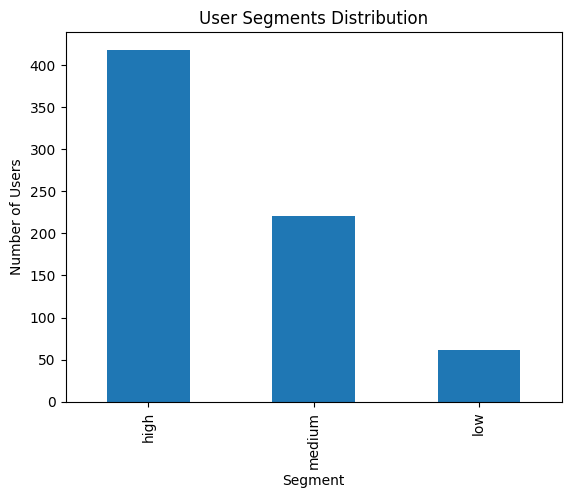

In [ ]:
import matplotlib.pyplot as plt

df['usage_segment'].value_counts().plot(kind='bar')
plt.title('User Segments Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Users')
plt.show()

In [ ]:
df.groupby('usage_segment')[
    [
        'app_usage_time_min_per_day',
        'screen_on_time_hours_per_day',
        'data_usage_mb_per_day',
        'battery_drain_mah_per_day'
    ]
].mean()

,app_usage_time_min_per_day,screen_on_time_hours_per_day,data_usage_mb_per_day,battery_drain_mah_per_day
usage_segment,,,,
high,388.287081,7.283971,1333.485646,2097.363636
low,43.590164,1.506557,195.737705,444.262295
medium,112.339367,2.508145,368.701357,741.235294


In [ ]:
df.groupby('operating_system')[
    'app_usage_time_min_per_day'
].mean()

,app_usage_time_min_per_day
operating_system,
Android,268.258123
iOS,282.020548


In [ ]:
df.groupby('number_of_apps_installed')[
    'app_usage_time_min_per_day'
].mean()

,app_usage_time_min_per_day
number_of_apps_installed,
10,58.812500
11,54.583333
12,66.100000
13,71.928571
14,61.769231
...,...
95,553.500000
96,534.666667
97,541.000000


In [ ]:
df.groupby('age')[
    'app_usage_time_min_per_day'
].mean()

,app_usage_time_min_per_day
age,
18,264.272727
19,248.583333
20,282.764706
21,332.352941
22,344.708333
23,282.533333
24,278.857143
25,238.000000
26,216.500000


In [ ]:
df.groupby('usage_segment')[
    [
        'data_usage_mb_per_day',
        'battery_drain_mah_per_day'
    ]
].mean()

,data_usage_mb_per_day,battery_drain_mah_per_day
usage_segment,,
high,1333.485646,2097.363636
low,195.737705,444.262295
medium,368.701357,741.235294


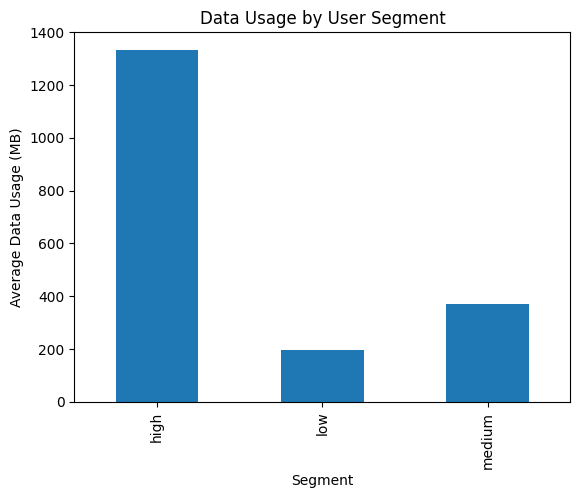

In [ ]:
df.groupby('usage_segment')[
    'data_usage_mb_per_day'
].mean().plot(kind='bar')

plt.title('Data Usage by User Segment')
plt.xlabel('Segment')
plt.ylabel('Average Data Usage (MB)')
plt.show()

## коментарии

- Пользователи сегмента high значительно превосходят остальные по времени использования
- У них выше потребление данных и батареи
- Low users составляют большинство - это потенциал роста

## рекомендаци

- Улучшить onboarding для low users
- Добавить премиум-функции для high users
- Оптимизировать потребление батареи